In [42]:
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt

In [7]:
PROJECT_ROOT = Path.cwd().parent
RAW_DATA_DIR = PROJECT_ROOT.parent / "data" / "pmdata" /  "raw"
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "pmdata" / "processed"

In [9]:
# check excel file
participants_overview = pd.read_excel(f"{RAW_DATA_DIR}/participant-overview.xlsx")

In [45]:
participants_overview.columns

Index(['Participant ID', 'Age', 'Height', 'Gender', 'A or B person',
       'Max heart rate', 'Date', 'Minutes', 'Seconds', 'Stride walk',
       'Stride run'],
      dtype='object')

In [11]:
participants_overview.head()

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,1st 5km run,Unnamed: 7,Unnamed: 8,Stride length from fitbit,Unnamed: 10
0,Participant ID,Age,Height,Gender,A or B person,Max heart rate,Date,Minutes,Seconds,Stride walk,Stride run
1,p01,48,195,male,A,182,2019-11-26 00:00:00,29,33,80.9,102.9
2,p02,60,180,male,A,169,2019-12-15 00:00:00,23,51,74.7,92.4
3,p03,25,184,male,A,157,2019-12-30 00:00:00,33,22,NaN,NaN
4,p04,26,163,female,A,195,2019-11-19 00:00:00,22,13,67.3,110.2


In [15]:
participants_overview = pd.read_excel(f"{RAW_DATA_DIR}/participant-overview.xlsx", skiprows=1)

In [21]:
participants_overview['Age'].describe()

count    16.000000
mean     34.875000
std      11.672618
min      23.000000
25%      26.000000
50%      29.000000
75%      42.750000
max      60.000000
Name: Age, dtype: float64

In [29]:
gender_counts = participants_overview['Gender'].value_counts()
gender_counts

Gender
male      12
female     3
male       1
Name: count, dtype: int64

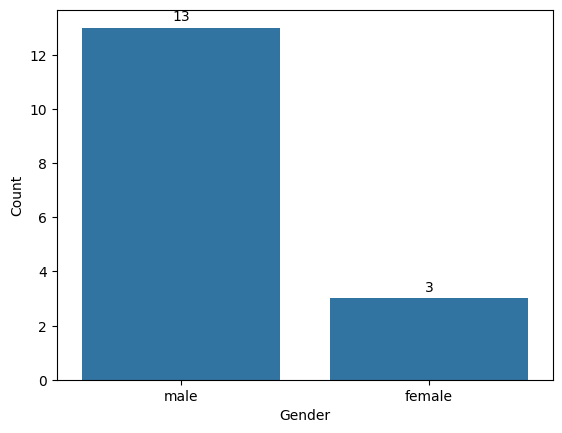

In [44]:
#  male apeared twice, must be whitespace in one of them
participants_overview["Gender"] = [gndr.strip() for gndr in participants_overview["Gender"]]
ax = sns.countplot(data=participants_overview, x="Gender")
ax.set(xlabel="Gender", ylabel="Count")
for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.show()

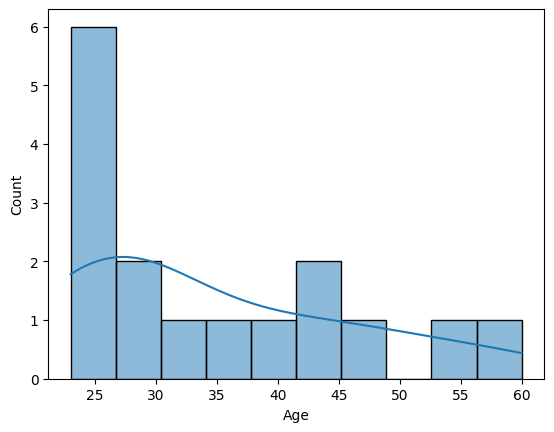

In [46]:
sns.histplot(data=participants_overview, x="Age", bins=10, kde=True)
plt.show()